# Bitcoin Price Regime Shifts: Bayesian MCMC + Hidden Markov Model
### Replication & Extension of Pakštaitė et al. (2025) — *Mathematics 13(10), 1577*

| | |
|---|---|
| **Data sources** | Yahoo Finance, Blockchain.com Charts API, FRED, alternative.me |
| **Original variables** | 16 macroeconomic + Bitcoin-specific factors (2016–2024) |
| **New variables** | `ETH_USD`, `US10Y`, `FEDFUNDS`, `FEAR_GREED` (Reddit/social sentiment) |
| **Extensions** | **3-state HMM** (Bull / Neutral / Bear) + sentiment variable (paper's future research) |

In [1]:
# ── CELL 1: Setup ─────────────────────────────────────────────────────────────
!pip install yfinance requests scikit-learn scipy matplotlib seaborn tqdm -q

import numpy as np, pandas as pd, requests, warnings
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from IPython.display import display
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.figsize': (15, 5), 'axes.grid': True, 'grid.alpha': 0.3})

START, END = '2016-06-01', '2024-12-01'
print('✓ Setup complete')

zsh:1: command not found: pip


✓ Setup complete


In [2]:
# ── CELL 2: Yahoo Finance Data ─────────────────────────────────────────────────
YF_MAP = {
    'BTC_USD': ('BTC-USD',  'Close'),
    'VOL':     ('BTC-USD',  'Volume'),
    'ETH_USD': ('ETH-USD',  'Close'),    # ★ NEW: crypto market breadth
    'DJI':     ('^DJI',     'Close'),
    'IXIC':    ('^IXIC',    'Close'),
    'SPX':     ('^GSPC',    'Close'),
    'VIX':     ('^VIX',     'Close'),
    'CNYUSD':  ('CNYUSD=X', 'Close'),
    'EURUSD':  ('EURUSD=X', 'Close'),
    'GBPUSD':  ('GBPUSD=X', 'Close'),
    'JPYUSD':  ('JPY=X',    'Close'),    # will invert → USD per JPY
    'GC_F':    ('GC=F',     'Close'),
    'CL_F':    ('CL=F',     'Close'),
    'US10Y':   ('^TNX',     'Close'),    # ★ NEW: 10-Year Treasury Yield
}

frames = {}
for name, (tkr, fld) in YF_MAP.items():
    try:
        raw = yf.download(tkr, start=START, end=END, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        frames[name] = raw[fld].squeeze() if fld in raw.columns else raw.iloc[:, 0].squeeze()
    except Exception as e:
        print(f'  ⚠ {name}: {e}')

df = pd.DataFrame(frames)
df.index = pd.to_datetime(df.index).tz_localize(None)
df['JPYUSD'] = 1.0 / df['JPYUSD']   # USD per JPY
print(f'✓ Yahoo Finance: {df.shape[1]} series | {df.index[0].date()} → {df.index[-1].date()}')

✓ Yahoo Finance: 14 series | 2016-06-01 → 2024-11-30


In [3]:
# ── CELL 3: Blockchain.com + FRED + Fear & Greed (Reddit/Social Sentiment) ────
def fetch_blockchain(metric):
    url = f'https://api.blockchain.info/charts/{metric}?timespan=all&format=json'
    try:
        data = requests.get(url, timeout=30).json()['values']
        return pd.Series({pd.Timestamp(d['x'], unit='s'): d['y'] for d in data})
    except Exception as e:
        print(f'  ⚠ blockchain/{metric}: {e}'); return pd.Series(dtype=float)

def fetch_fred(sid):
    try:
        s = pd.read_csv(f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}',
                        index_col=0, parse_dates=True).squeeze()
        return pd.to_numeric(s, errors='coerce').dropna()
    except Exception as e:
        print(f'  ⚠ FRED/{sid}: {e}'); return pd.Series(dtype=float)

def fetch_yahoo_series(tkr):
    """Yahoo Finance fallback for rate series when FRED is unreachable."""
    try:
        raw = yf.download(tkr, start=START, end=END, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        s = raw['Close'].squeeze() if 'Close' in raw.columns else raw.iloc[:, 0].squeeze()
        return pd.to_numeric(s, errors='coerce').dropna()
    except Exception as e:
        print(f'  ⚠ yahoo/{tkr}: {e}'); return pd.Series(dtype=float)

def fetch_fear_greed():
    """
    Crypto Fear & Greed Index (alternative.me)
    Incorporates: volatility, market momentum/volume, social media
    (Reddit + Twitter posts/engagement), surveys, BTC dominance, Google Trends.
    Score 0-100: 0=Extreme Fear, 100=Extreme Greed.
    This is the best publicly available Reddit/social sentiment proxy.
    Paper future research: 'adding sentiment or social-media-based indicators'
    """
    url = 'https://api.alternative.me/fng/?limit=3000&format=json'
    try:
        data = requests.get(url, timeout=30).json()['data']
        s = pd.Series(
            {pd.Timestamp(int(d['timestamp']), unit='s'): float(d['value']) for d in data}
        ).sort_index()
        print(f'  ✓ FEAR_GREED (Fear & Greed Index): {len(s)} daily points')
        return s
    except Exception as e:
        print(f'  ⚠ Fear & Greed: {e}'); return pd.Series(dtype=float)

# Blockchain.com
print('Blockchain.com...')
for col, metric in [('HASH','hash-rate'),('BLOCK','avg-block-size'),('MINER','miners-revenue')]:
    s = fetch_blockchain(metric)
    if not s.empty:
        s.index = pd.to_datetime(s.index).tz_localize(None)
        df[col] = s.reindex(df.index, method='nearest')
        print(f'  ✓ {col}')

# FRED — with automatic Yahoo Finance fallback if FRED is unreachable
# INFL     T5YIE (5Y breakeven inflation)  → fallback ^FVX (5Y Treasury yield)
# FEDFUNDS DFF   (effective fed funds rate) → fallback ^IRX (13W T-bill rate)
print('FRED / rates...')
FRED_FALLBACK = {'INFL': '^FVX', 'FEDFUNDS': '^IRX'}
for col, sid in [('INFL','T5YIE'), ('FEDFUNDS','DFF')]:
    s = fetch_fred(sid)
    src = f'FRED {sid}'
    if s.empty:
        s = fetch_yahoo_series(FRED_FALLBACK[col])
        src = f'{FRED_FALLBACK[col]} (Yahoo proxy)'
    if not s.empty:
        s.index = pd.to_datetime(s.index).tz_localize(None)
        df[col] = s.reindex(df.index, method='ffill').bfill()
        print(f'  ✓ {col} ← {src}{" ★ NEW" if col=="FEDFUNDS" else ""}')
    else:
        print(f'  ⚠ {col}: unavailable from FRED and Yahoo — skipped')

# Fear & Greed (Reddit/Social Sentiment) — paper future research
print('Sentiment (Reddit/Social proxy)...')
fg = fetch_fear_greed()
if not fg.empty:
    fg.index = pd.to_datetime(fg.index).tz_localize(None)
    df['FEAR_GREED'] = fg.reindex(df.index, method='nearest')

print(f'\n✓ Total columns: {df.shape[1]}')
_show = [c for c in ['HASH','BLOCK','MINER','INFL','FEDFUNDS','FEAR_GREED'] if c in df.columns]
df[_show].tail(3)

Blockchain.com...


  ✓ HASH


  ✓ BLOCK


  ✓ MINER
FRED / rates...


  ⚠ FRED/T5YIE: HTTP Error 504: Gateway Time-out


  ✓ INFL ← ^FVX (Yahoo proxy)


  ⚠ FRED/DFF: HTTP Error 504: Gateway Time-out


  ✓ FEDFUNDS ← ^IRX (Yahoo proxy) ★ NEW
Sentiment (Reddit/Social proxy)...


  ✓ FEAR_GREED (Fear & Greed Index): 3000 daily points

✓ Total columns: 20


,HASH,BLOCK,MINER,INFL,FEDFUNDS,FEAR_GREED
Date,,,,,,
2024-11-28,7.220464e+08,1.63426,5.121991e+07,4.113,4.385,77.0
2024-11-29,7.220464e+08,1.63426,5.121991e+07,4.055,4.373,78.0
2024-11-30,6.495828e+08,1.63426,5.121991e+07,4.055,4.373,84.0


In [4]:
# ── CELL 4: Feature Engineering & Processing ──────────────────────────────────
HALVINGS = pd.to_datetime(['2016-07-09','2020-05-11','2024-04-19','2028-03-26'])
def days_until_halving(dt):
    future = HALVINGS[HALVINGS > dt]
    return (future[0] - dt).days if len(future) else np.nan
df['HALVING'] = pd.Series([days_until_halving(d) for d in df.index], index=df.index)

# Variable sets
ORIGINAL   = ['DJI','IXIC','SPX','VIX','INFL','CNYUSD','EURUSD','GBPUSD',
               'JPYUSD','GC_F','CL_F','VOL','BLOCK','HASH','MINER','HALVING']
NEW_VARS   = ['ETH_USD','US10Y','FEDFUNDS','FEAR_GREED']  # ★ 4 new variables
TARGET     = 'BTC_USD'

# Keep only variables that actually loaded (robust to a failed data source)
missing    = [v for v in ORIGINAL + NEW_VARS if v not in df.columns]
if missing:
    print(f'  ⚠ Dropping unavailable variables: {missing}')
ORIGINAL   = [v for v in ORIGINAL if v in df.columns]
NEW_VARS   = [v for v in NEW_VARS if v in df.columns]
ALL_VARS   = ORIGINAL + NEW_VARS

# Drop degenerate columns (all-NaN or zero-variance, e.g. an unfetched FX pair)
_keep = [TARGET] + ALL_VARS
_var  = df[_keep].std(numeric_only=True)
_dead = [c for c in ALL_VARS if c not in _var.index or not np.isfinite(_var[c]) or _var[c] == 0]
if _dead:
    print(f'  ⚠ Dropping zero-variance/empty variables: {_dead}')
    ORIGINAL = [v for v in ORIGINAL if v not in _dead]
    NEW_VARS = [v for v in NEW_VARS if v not in _dead]
    ALL_VARS = ORIGINAL + NEW_VARS

# Clip Fear & Greed at 1 (score 0 causes log(-inf)), then log + scale
df_work = df[[TARGET] + ALL_VARS].copy()
df_log  = np.log(df_work.clip(lower=1.0)).interpolate('linear').ffill().bfill()

scaler   = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_log),
                          index=df_log.index, columns=df_log.columns)

# 7-day lag on all covariates (as in paper)
df_model = df_scaled[[TARGET]].copy()
for col in ALL_VARS:
    df_model[col] = df_scaled[col].shift(7)
df_model.dropna(inplace=True)

SAMPLES = {
    'Early  (2016-08→2019-08)': ('2016-08-01','2019-08-31'),
    'Recent (2019-09→2024-12)': ('2019-09-01','2024-11-30'),
    'Full   (2016-08→2024-12)': ('2016-08-01','2024-11-30'),
}

print(f'✓ Processed: {df_model.shape}')
print(f'  Original variables : {len(ORIGINAL)}')
print(f'  New variables (★)  : {NEW_VARS}')
print(f'    FEAR_GREED → Reddit/social sentiment proxy (alternative.me)')
print(f'    ETH_USD    → Ethereum price / crypto market breadth')
print(f'    US10Y      → 10-Year Treasury Yield')
print(f'    FEDFUNDS   → Federal Funds Rate (monetary policy)')
for lbl,(s,e) in SAMPLES.items():
    print(f'  {lbl}: n={len(df_model[s:e])}')

tbl = df_model.describe().T[['mean','std','min','50%','max']].round(3)
tbl.columns = ['Mean','Std','Min','Median','Max']
display(tbl)

✓ Processed: (3098, 21)
  Original variables : 16
  New variables (★)  : ['ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED']
    FEAR_GREED → Reddit/social sentiment proxy (alternative.me)
    ETH_USD    → Ethereum price / crypto market breadth
    US10Y      → 10-Year Treasury Yield
    FEDFUNDS   → Federal Funds Rate (monetary policy)
  Early  (2016-08→2019-08): n=1126
  Recent (2019-09→2024-12): n=1918
  Full   (2016-08→2024-12): n=3044


,Mean,Std,Min,Median,Max
BTC_USD,0.005,0.995,-2.360,0.002,1.595
DJI,-0.005,0.997,-2.281,-0.008,1.981
IXIC,-0.004,0.998,-2.066,0.182,1.797
SPX,-0.005,0.997,-1.910,-0.055,2.018
VIX,0.001,1.001,-1.833,-0.124,4.507
INFL,-0.003,0.999,-1.415,-0.030,1.643
CNYUSD,0.000,0.000,0.000,0.000,0.000
EURUSD,0.003,0.999,-2.345,-0.078,2.288
GBPUSD,0.001,1.001,-3.919,0.009,2.919
JPYUSD,0.000,0.000,0.000,0.000,0.000


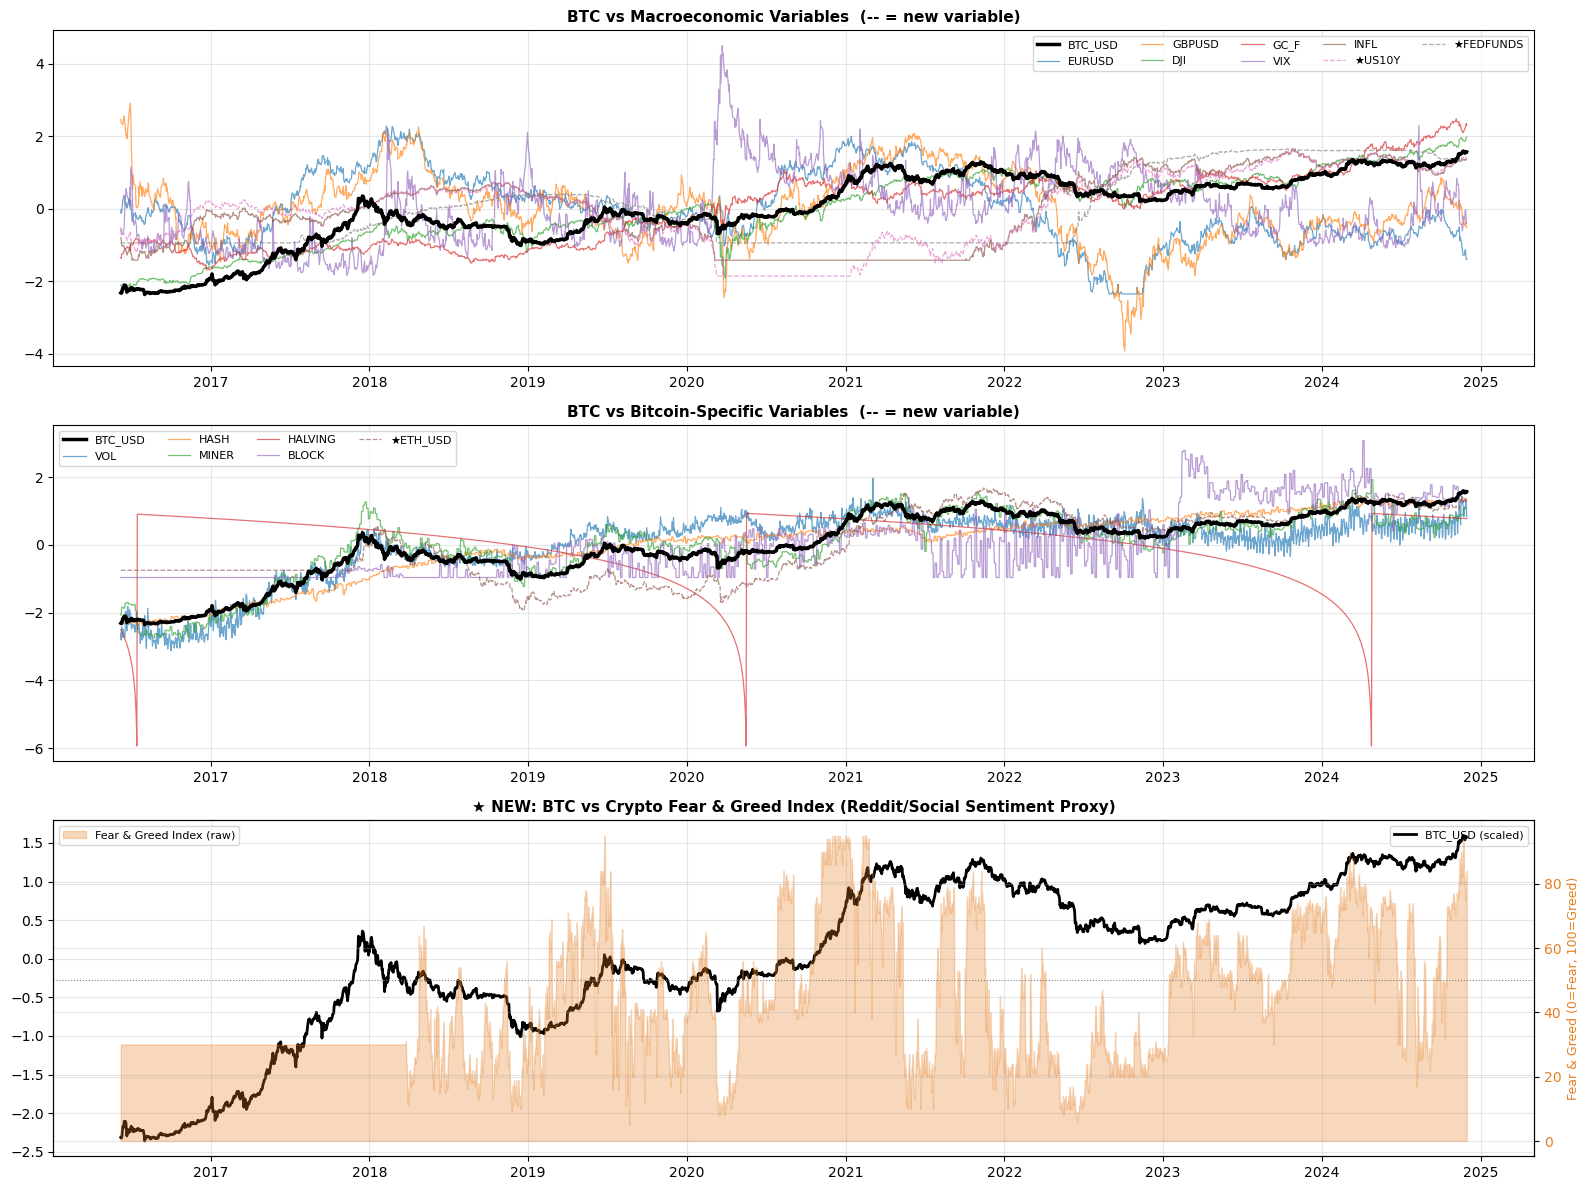

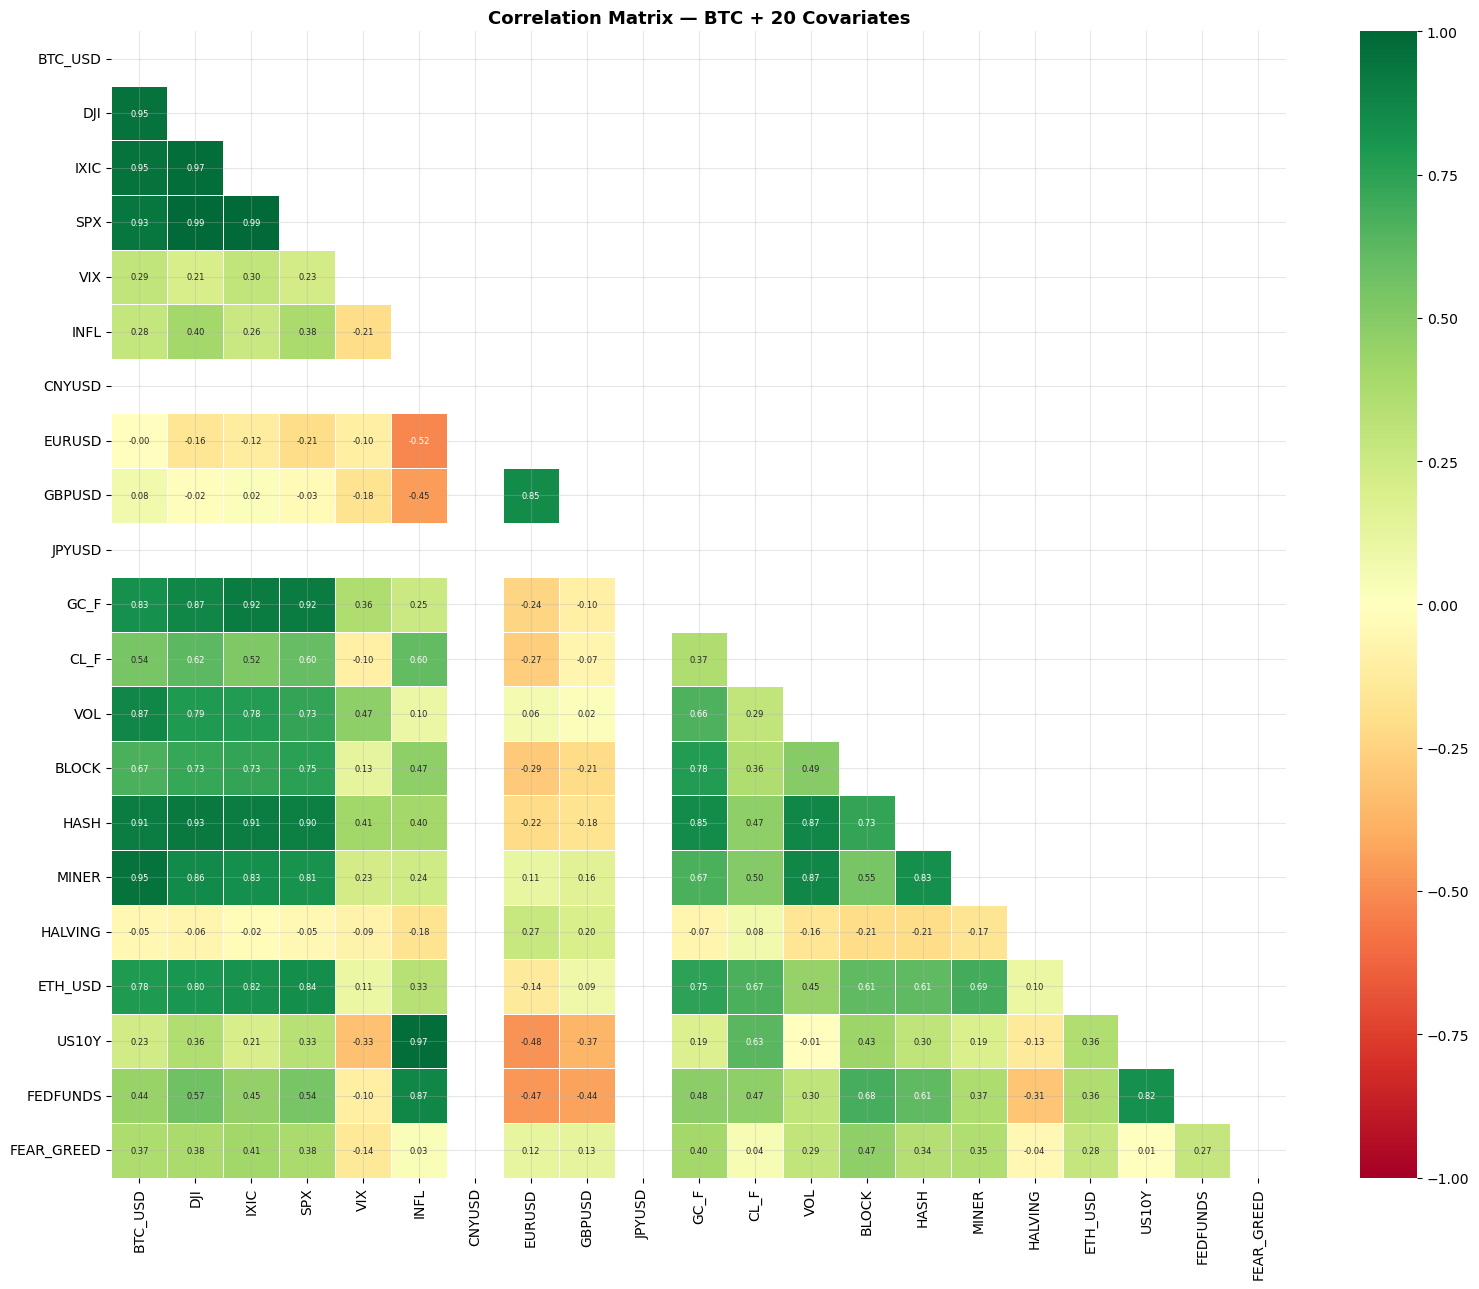

In [5]:
# ── CELL 5: EDA ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Panel 1: Macroeconomic
macro_plot = ['EURUSD','GBPUSD','DJI','GC_F','VIX','INFL','US10Y','FEDFUNDS']
ax = axes[0]
ax.plot(df_model.index, df_model[TARGET], 'k-', lw=2.5, label='BTC_USD', zorder=10)
for c in macro_plot:
    if c in df_model.columns:
        ax.plot(df_model.index, df_model[c], lw=0.9, alpha=0.65,
                ls='--' if c in NEW_VARS else '-',
                label=f"{'★' if c in NEW_VARS else ''}{c}")
ax.set_title('BTC vs Macroeconomic Variables  (-- = new variable)', fontsize=11, fontweight='bold')
ax.legend(ncol=5, fontsize=8)

# Panel 2: Bitcoin-specific
btc_plot = ['VOL','HASH','MINER','HALVING','BLOCK','ETH_USD']
ax = axes[1]
ax.plot(df_model.index, df_model[TARGET], 'k-', lw=2.5, label='BTC_USD', zorder=10)
for c in btc_plot:
    if c in df_model.columns:
        ax.plot(df_model.index, df_model[c], lw=0.9, alpha=0.65,
                ls='--' if c in NEW_VARS else '-',
                label=f"{'★' if c in NEW_VARS else ''}{c}")
ax.set_title('BTC vs Bitcoin-Specific Variables  (-- = new variable)', fontsize=11, fontweight='bold')
ax.legend(ncol=4, fontsize=8)

# Panel 3: Sentiment (FEAR_GREED) — paper future research
ax = axes[2]
ax2_twin = ax.twinx()
ax.plot(df_model.index, df_model[TARGET], 'k-', lw=2, label='BTC_USD (scaled)', zorder=10)
if 'FEAR_GREED' in df_model.columns:
    raw_fg = df['FEAR_GREED'].reindex(df_model.index)
    ax2_twin.fill_between(df_model.index, raw_fg, alpha=0.3, color='#e67e22', label='Fear & Greed Index (raw)')
    ax2_twin.axhline(50, color='gray', ls=':', lw=0.8)
    ax2_twin.set_ylabel('Fear & Greed (0=Fear, 100=Greed)', color='#e67e22', fontsize=9)
    ax2_twin.tick_params(axis='y', labelcolor='#e67e22')
    ax2_twin.legend(loc='upper left', fontsize=8)
ax.set_title('★ NEW: BTC vs Crypto Fear & Greed Index (Reddit/Social Sentiment Proxy)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('eda_all_vars.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlation heatmap
corr = df_model.corr()
plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.4, annot_kws={'size': 6})
plt.title('Correlation Matrix — BTC + 20 Covariates', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('corr_heatmap.png', dpi=120, bbox_inches='tight'); plt.show()

=== 2-State HMM (paper baseline) ===


  State 1 (Bull 🟢): 1861 days (60.1%) | μ_BTC=0.474 | σ²=0.0054
  State 0 (Bear 🔴): 1237 days (39.9%) | μ_BTC=-0.699 | σ²=0.0058
  Log-likelihood: 3480.50
  AIC: -6869.0

=== 3-State HMM (Bull / Neutral / Bear extension) ===


  State 0 (Neutral 🟡): 1342 days (43.3%) | μ_BTC=0.279 | σ²=0.0046
  State 1 (Bull 🟢): 1166 days (37.6%) | μ_BTC=0.439 | σ²=0.0025
  State 2 (Bear 🔴): 590 days (19.0%) | μ_BTC=-1.476 | σ²=0.0041
  Log-likelihood: 4029.82
  AIC: -7915.6  (lower = better fit)
  Transition matrix (A):


,→Neutral 🟡,→Bull 🟢,→Bear 🔴
Neutral 🟡,0.971,0.026,0.002
Bull 🟢,0.031,0.967,0.003
Bear 🔴,0.005,0.007,0.988


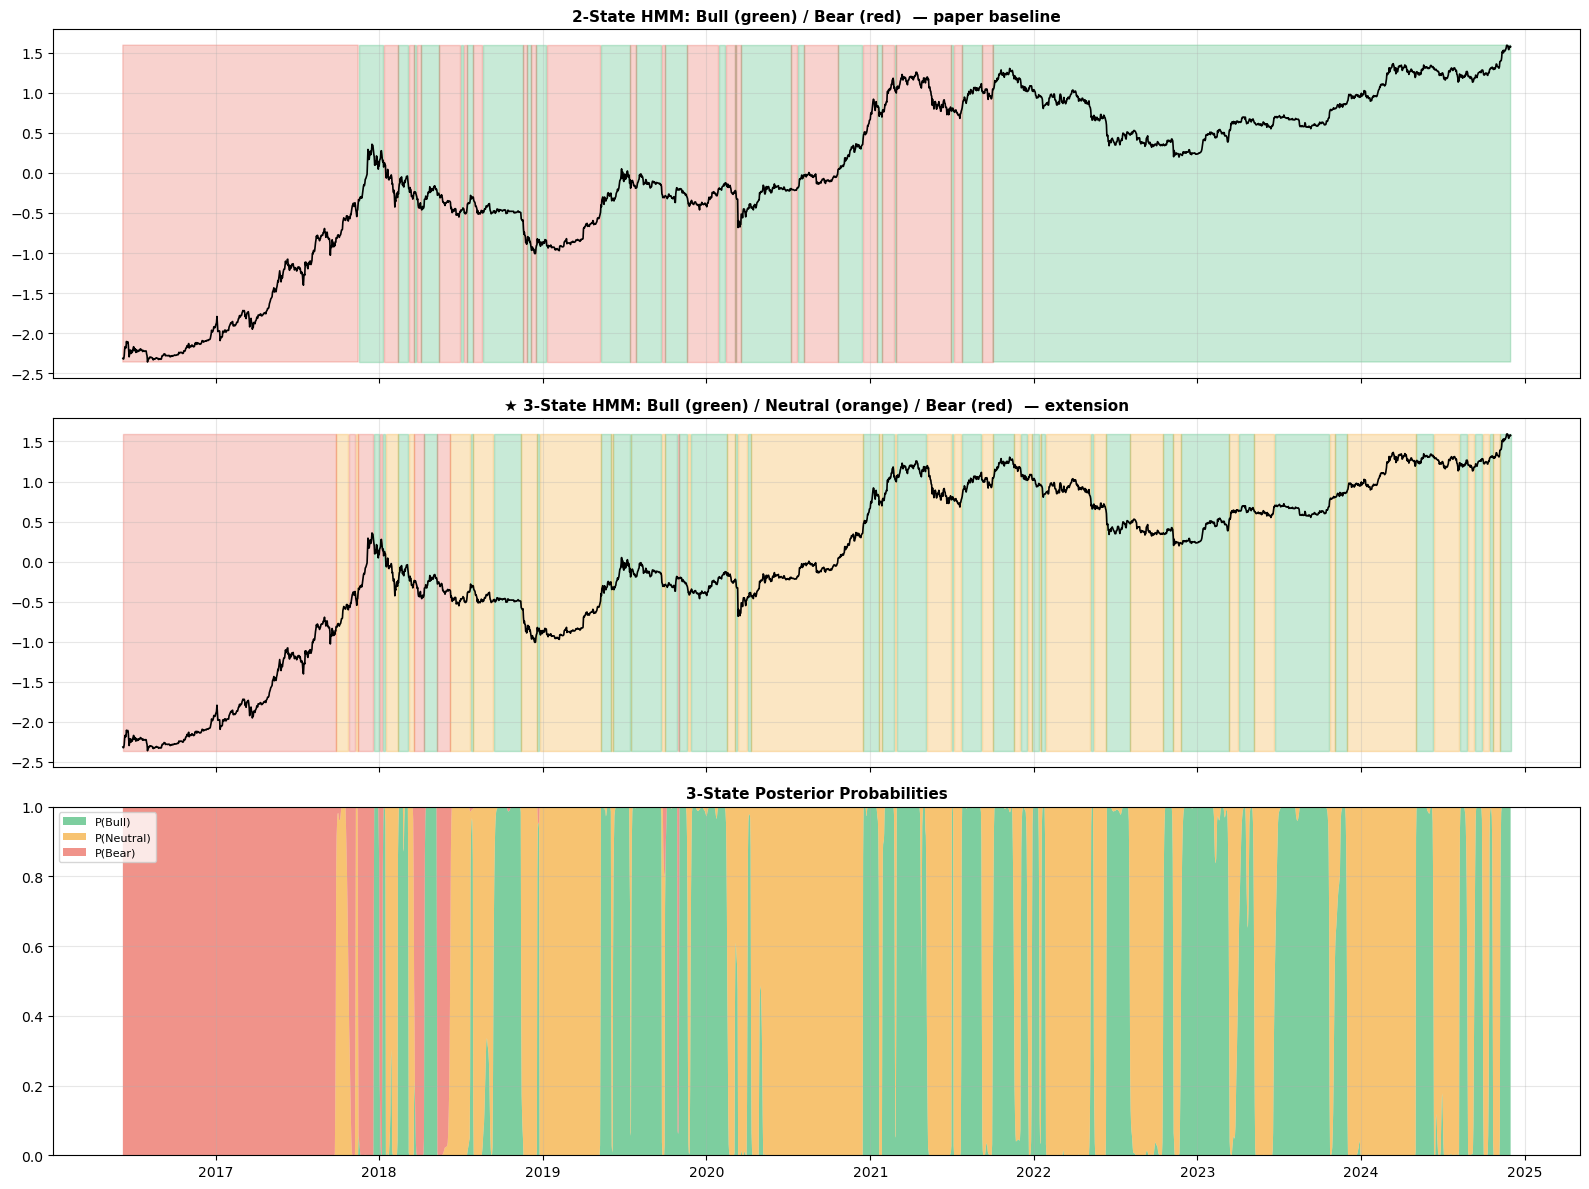

In [6]:
# ── CELL 6: Switching Regression HMM (supports 2 OR 3 states) ─────────────────
class SwitchingHMM:
    """
    K-state switching regression HMM.
    Emission: Y_t | Z_t=s, X_t ~ N(X_t @ B_s, sigma2_s)   [paper eq. 1]
    Transitions: fixed P(Z_{t+1}=j | Z_t=i) = A[i,j]       [paper eq. 2]
    Fitted via Baum-Welch EM. Supports K=2 (paper) or K=3 (extension).
    """
    def __init__(self, n_states=2, n_iter=80):
        self.K, self.n_iter = n_states, n_iter

    def _emit(self, Y, X):
        E = np.zeros((len(Y), self.K))
        for s in range(self.K):
            mu = X @ self.B[s]
            E[:, s] = stats.norm.pdf(Y, mu, max(np.sqrt(self.sigma2[s]), 1e-8))
        return np.clip(E, 1e-300, None)

    def _fwd_bwd(self, Y, X):
        E = self._emit(Y, X)
        T, K = len(Y), self.K
        alpha, sc = np.zeros((T, K)), np.zeros(T)
        alpha[0] = self.pi * E[0]; sc[0] = alpha[0].sum(); alpha[0] /= sc[0]
        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ self.A) * E[t]
            sc[t] = alpha[t].sum(); alpha[t] /= (sc[t] or 1e-300)
        beta = np.ones((T, K))
        for t in range(T-2, -1, -1):
            beta[t] = (self.A * E[t+1] * beta[t+1]).sum(1)
            beta[t] /= (beta[t].sum() or 1e-300)
        gamma = alpha * beta
        gamma /= gamma.sum(1, keepdims=True)
        xi_num = alpha[:-1, :, None] * self.A[None] * E[1:, None, :] * beta[1:, None, :]
        xi = xi_num / (xi_num.sum((1,2), keepdims=True) + 1e-300)
        return gamma, xi, np.sum(np.log(sc + 1e-300))

    def fit(self, Y, X):
        T, p = X.shape; K = self.K
        labels = KMeans(n_clusters=K, n_init=5, random_state=42).fit_predict(Y.reshape(-1,1))
        self.pi = np.array([(labels==s).mean() for s in range(K)]) + 1e-3; self.pi /= self.pi.sum()
        eps = 0.05/(K-1)
        self.A = np.full((K, K), eps); np.fill_diagonal(self.A, 1 - eps*(K-1))
        self.B = np.zeros((K, p)); self.sigma2 = np.ones(K)
        for s in range(K):
            idx = labels == s
            if idx.sum() > p:
                self.B[s] = np.linalg.lstsq(X[idx], Y[idx], rcond=None)[0]
                self.sigma2[s] = max(np.var(Y[idx] - X[idx] @ self.B[s]), 1e-6)
        prev_ll = -np.inf
        for _ in range(self.n_iter):
            gamma, xi, ll = self._fwd_bwd(Y, X)
            if abs(ll - prev_ll) < 1e-5: break
            prev_ll = ll
            self.pi = gamma[0] + 1e-10; self.pi /= self.pi.sum()
            self.A  = xi.sum(0) + 1e-10; self.A /= self.A.sum(1, keepdims=True)
            for s in range(K):
                w = gamma[:, s] + 1e-10
                XtWX = (X.T * w) @ X + 1e-6 * np.eye(p)
                try:
                    self.B[s] = np.linalg.solve(XtWX, (X.T * w) @ Y)
                    r = Y - X @ self.B[s]
                    self.sigma2[s] = max((w * r**2).sum() / w.sum(), 1e-6)
                except: pass
        self.gamma_ = gamma; self.states_ = gamma.argmax(1); self.ll_ = ll
        return self

    def score(self, Y, X):
        _, _, ll = self._fwd_bwd(Y, X); return ll


# ── A) 2-State HMM (paper baseline) ───────────────────────────────────────────
Y_full = df_model[TARGET].values
X_full = np.column_stack([np.ones(len(Y_full)), df_model[ALL_VARS].values])

print('=== 2-State HMM (paper baseline) ===')
hmm2 = SwitchingHMM(n_states=2, n_iter=100).fit(Y_full, X_full)
s2   = hmm2.states_
bull2 = int(np.argmax([Y_full[s2==s].mean() for s in range(2)]))
bear2 = 1 - bull2
for s, lbl in [(bull2,'Bull 🟢'),(bear2,'Bear 🔴')]:
    n = (s2==s).sum()
    print(f'  State {s} ({lbl}): {n} days ({100*n/len(s2):.1f}%) | '
          f'μ_BTC={Y_full[s2==s].mean():.3f} | σ²={hmm2.sigma2[s]:.4f}')
print(f'  Log-likelihood: {hmm2.ll_:.2f}')
print(f'  AIC: {-2*hmm2.ll_ + 2*(2*X_full.shape[1]+4):.1f}')

# ── B) 3-State HMM (extension — Bull / Neutral / Bear) ────────────────────────
print('\n=== 3-State HMM (Bull / Neutral / Bear extension) ===')
hmm3 = SwitchingHMM(n_states=3, n_iter=100).fit(Y_full, X_full)
s3   = hmm3.states_
means3 = [Y_full[s3==s].mean() for s in range(3)]
order3 = np.argsort(means3)  # ascending: bear, neutral, bull
state3_names = {order3[0]: 'Bear 🔴', order3[1]: 'Neutral 🟡', order3[2]: 'Bull 🟢'}

for s in range(3):
    n = (s3==s).sum()
    print(f'  State {s} ({state3_names[s]}): {n} days ({100*n/len(s3):.1f}%) | '
          f'μ_BTC={means3[s]:.3f} | σ²={hmm3.sigma2[s]:.4f}')
print(f'  Log-likelihood: {hmm3.ll_:.2f}')
p3 = X_full.shape[1]
print(f'  AIC: {-2*hmm3.ll_ + 2*(3*p3+9):.1f}  (lower = better fit)')
print(f'  Transition matrix (A):')
A_df = pd.DataFrame(hmm3.A, columns=[f'→{state3_names[j]}' for j in range(3)],
                     index=[state3_names[i] for i in range(3)])
display(A_df.round(3))

# ── Plot: 2-state vs 3-state regimes ──────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
COLORS2 = {bull2: '#27ae60', bear2: '#e74c3c'}
COLORS3 = {order3[2]: '#27ae60', order3[1]: '#f39c12', order3[0]: '#e74c3c'}

ax = axes[0]
ax.plot(df_model.index, Y_full, 'k-', lw=1.2)
for s, c in COLORS2.items():
    ax.fill_between(df_model.index, Y_full.min(), Y_full.max(),
                     where=(s2==s), alpha=0.25, color=c)
ax.set_title('2-State HMM: Bull (green) / Bear (red)  — paper baseline', fontsize=11, fontweight='bold')

ax = axes[1]
ax.plot(df_model.index, Y_full, 'k-', lw=1.2)
for s, c in COLORS3.items():
    ax.fill_between(df_model.index, Y_full.min(), Y_full.max(),
                     where=(s3==s), alpha=0.25, color=c)
ax.set_title('★ 3-State HMM: Bull (green) / Neutral (orange) / Bear (red)  — extension', fontsize=11, fontweight='bold')

ax = axes[2]
colors_seq = [COLORS3[s] for s in s3]
ax.stackplot(df_model.index,
              hmm3.gamma_[:, order3[2]], hmm3.gamma_[:, order3[1]], hmm3.gamma_[:, order3[0]],
              colors=['#27ae60','#f39c12','#e74c3c'], alpha=0.6,
              labels=['P(Bull)','P(Neutral)','P(Bear)'])
ax.set_title('3-State Posterior Probabilities', fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=8); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('regimes_2v3_state.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# ── CELL 7: Bayesian MCMC Variable Selection ───────────────────────────────────
# Simplified Double Reversible Jump MCMC (paper Section 2.1)
# State-conditioned Gibbs-style likelihood; states refreshed every 100 iterations
# Supports both 2-state and 3-state HMMs

def state_cond_lik(Y, X_all, ones_col, sel_idx, states, K):
    X_sel = np.hstack([ones_col, X_all[:, sel_idx]]) if sel_idx else ones_col
    ll = 0.0
    for s in range(K):
        idx = states == s
        if idx.sum() <= X_sel.shape[1]: continue
        Xs, Ys = X_sel[idx], Y[idx]
        try:
            B = np.linalg.lstsq(Xs, Ys, rcond=None)[0]
            r = Ys - Xs @ B
            ll += np.sum(stats.norm.logpdf(r, 0, np.sqrt(max(np.var(r), 1e-8))))
        except:
            ll -= 1e6
    return ll

def mcmc_var_select(Y, df_covs, K=2, n_iter=800, pen_add=0.1,
                     pen_step=0.05, burn_frac=0.3, refresh=100):
    cols   = list(df_covs.columns)
    X_all  = df_covs.values
    T, nc  = len(Y), len(cols)
    ones_c = np.ones((T, 1))
    burn   = int(n_iter * burn_frac)

    # Bootstrap state sequence
    init_idx = list(range(min(3, nc)))
    X_init   = np.hstack([ones_c, X_all[:, init_idx]])
    states   = SwitchingHMM(n_states=K, n_iter=50).fit(Y, X_init).states_

    cur_idx  = init_idx.copy()
    cur_lik  = state_cond_lik(Y, X_all, ones_c, cur_idx, states, K)
    counts   = np.zeros(nc)

    for it in tqdm(range(n_iter), desc=f'MCMC K={K}', leave=False):
        if it % refresh == 0 and it > 0:
            X_c = np.hstack([ones_c, X_all[:, cur_idx]]) if cur_idx else ones_c
            try:
                states  = SwitchingHMM(n_states=K, n_iter=30).fit(Y, X_c).states_
                cur_lik = state_cond_lik(Y, X_all, ones_c, cur_idx, states, K)
            except: pass

        can_add = [i for i in range(nc) if i not in cur_idx]
        can_rem = cur_idx.copy()

        if not can_add or (can_rem and np.random.rand() < 0.5):
            prop = can_rem.copy(); prop.remove(np.random.choice(can_rem)); pen = 0.0
        else:
            prop = cur_idx + [np.random.choice(can_add)]
            pen  = pen_add if len(prop) > len(cur_idx) + 1 else pen_step

        prop_lik = state_cond_lik(Y, X_all, ones_c, prop, states, K)
        if np.log(max(np.random.rand(), 1e-300)) < (prop_lik - cur_lik - pen):
            cur_idx, cur_lik = prop, prop_lik

        if it >= burn:
            for i in cur_idx: counts[i] += 1

    return dict(sorted({cols[i]: round(counts[i]/(n_iter-burn), 3) for i in range(nc)}.items(),
                         key=lambda x: -x[1]))

# ── Run MCMC: 2-state AND 3-state, for each subsample ─────────────────────────
pip2_results = {}   # 2-state PIP (paper)
pip3_results = {}   # 3-state PIP (extension)

for label, (s, e) in SAMPLES.items():
    sub = df_model[s:e]
    Y_s = sub[TARGET].values
    print(f"\n{'─'*55}\nPeriod: {label.strip()}  (n={len(sub)})")

    pip2 = mcmc_var_select(Y_s, sub[ALL_VARS], K=2, n_iter=1000)
    pip3 = mcmc_var_select(Y_s, sub[ALL_VARS], K=3, n_iter=1000)
    pip2_results[label] = pip2
    pip3_results[label] = pip3

    sel2 = [k for k,v in pip2.items() if v >= 0.5]
    sel3 = [k for k,v in pip3.items() if v >= 0.5]
    print(f'  2-State selected: {sel2}')
    print(f'  3-State selected: {sel3}')
    new2 = [v for v in sel2 if v in NEW_VARS]
    new3 = [v for v in sel3 if v in NEW_VARS]
    if new2 or new3:
        print(f'  ★ New vars in 2-state: {new2} | 3-state: {new3}')

# ── PIP comparison table ───────────────────────────────────────────────────────
all_pips = {}
for lbl in SAMPLES:
    all_pips[f'{lbl.strip()}|2-state'] = pip2_results[lbl]
    all_pips[f'{lbl.strip()}|3-state'] = pip3_results[lbl]

pip_df = pd.DataFrame(all_pips).fillna(0)
pip_df.insert(0, 'Source', ['★ New' if c in NEW_VARS else 'Paper' for c in pip_df.index])

num_cols = [c for c in pip_df.columns if c != 'Source']
print("\n" + "="*70)
print("POSTERIOR INCLUSION PROBABILITIES — 2-State vs 3-State")
print("Threshold: ≥0.5 (emission) as in paper Section 2.1")
print("="*70)
display(pip_df.style
        .background_gradient(subset=num_cols, cmap='YlOrRd', vmin=0, vmax=1)
        .format({c: '{:.3f}' for c in num_cols})
        .set_caption('★ = new variable | Green highlight = PIP ≥ 0.5'))


───────────────────────────────────────────────────────
Period: Early  (2016-08→2019-08)  (n=1126)



MCMC K=2:   0%|          | 0/1000 [00:00<?, ?it/s]


MCMC K=2:  10%|▉         | 97/1000 [00:00<00:00, 950.85it/s]


MCMC K=2:  19%|█▉        | 193/1000 [00:00<00:02, 403.15it/s]


MCMC K=2:  25%|██▌       | 250/1000 [00:00<00:02, 302.38it/s]

...


MCMC K=3:  80%|████████  | 801/1000 [00:05<00:01, 114.30it/s]


MCMC K=3:  89%|████████▉ | 894/1000 [00:06<00:00, 173.13it/s]


MCMC K=3:  94%|█████████▍| 941/1000 [00:06<00:00, 130.42it/s]

  2-State selected: ['DJI', 'IXIC', 'SPX', 'VIX', 'INFL', 'EURUSD', 'GBPUSD', 'GC_F', 'CL_F', 'VOL', 'BLOCK', 'HASH', 'MINER', 'HALVING', 'ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED', 'JPYUSD', 'CNYUSD']
  3-State selected: ['DJI', 'IXIC', 'SPX', 'VIX', 'INFL', 'EURUSD', 'GBPUSD', 'GC_F', 'CL_F', 'VOL', 'BLOCK', 'HASH', 'MINER', 'HALVING', 'ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED', 'JPYUSD', 'CNYUSD']
  ★ New vars in 2-state: ['ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED'] | 3-state: ['ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED']

POSTERIOR INCLUSION PROBABILITIES — 2-State vs 3-State
Threshold: ≥0.5 (emission) as in paper Section 2.1


,Source,Early (2016-08→2019-08)|2-state,Early (2016-08→2019-08)|3-state,Recent (2019-09→2024-12)|2-state,Recent (2019-09→2024-12)|3-state,Full (2016-08→2024-12)|2-state,Full (2016-08→2024-12)|3-state
DJI,Paper,1.000,1.000,1.000,1.000,1.000,1.000
IXIC,Paper,1.000,1.000,1.000,1.000,1.000,1.000
SPX,Paper,1.000,1.000,1.000,1.000,1.000,1.000
VIX,Paper,1.000,1.000,0.991,1.000,1.000,1.000
INFL,Paper,1.000,1.000,1.000,1.000,1.000,1.000
EURUSD,Paper,1.000,1.000,1.000,1.000,1.000,1.000
GC_F,Paper,1.000,1.000,1.000,1.000,1.000,1.000
CL_F,Paper,1.000,1.000,1.000,1.000,1.000,1.000
BLOCK,Paper,1.000,1.000,0.986,1.000,1.000,1.000
MINER,Paper,1.000,1.000,1.000,1.000,1.000,1.000


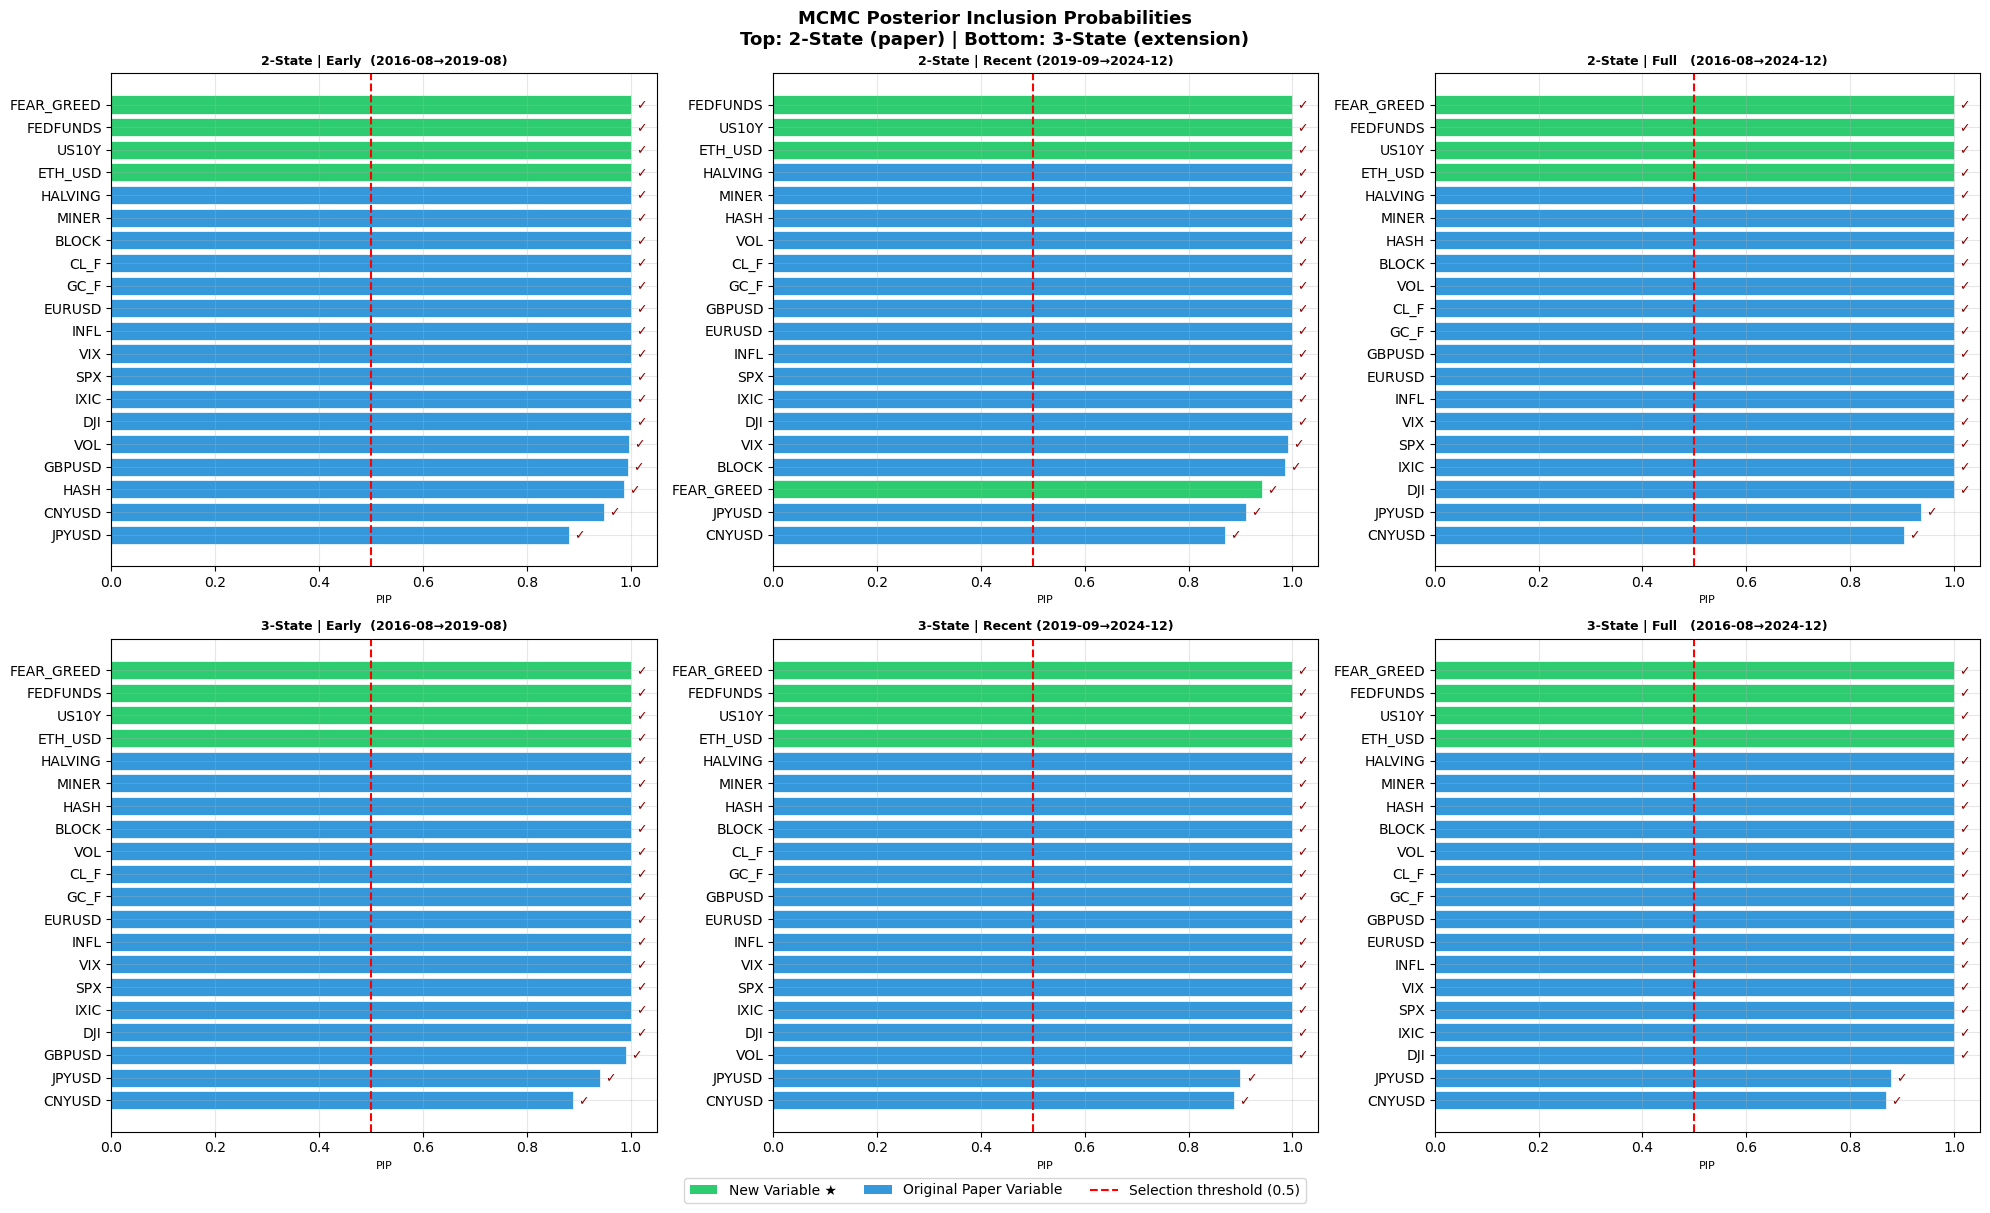

In [8]:
# ── CELL 7b: PIP Visualization — 2-State vs 3-State ───────────────────────────
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('MCMC Posterior Inclusion Probabilities\nTop: 2-State (paper) | Bottom: 3-State (extension)',
              fontsize=13, fontweight='bold')

for row, (pip_dict, row_label) in enumerate([(pip2_results, '2-State'), (pip3_results, '3-State')]):
    for col, (label, pip) in enumerate(pip_dict.items()):
        ax = axes[row][col]
        pip_s = dict(sorted(pip.items(), key=lambda x: x[1]))
        names  = list(pip_s.keys())
        vals   = list(pip_s.values())
        colors = ['#2ecc71' if n in NEW_VARS else ('#e74c3c' if n == 'FEAR_GREED' else '#3498db') for n in names]

        bars = ax.barh(names, vals, color=colors, edgecolor='white', linewidth=0.5)
        ax.axvline(0.5, color='red', ls='--', lw=1.5)
        ax.set_xlim(0, 1.05)
        ax.set_title(f'{row_label} | {label.strip()[:25]}', fontsize=9, fontweight='bold')
        ax.set_xlabel('PIP', fontsize=8)
        for bar, v in zip(bars, vals):
            if v >= 0.5:
                ax.text(v+0.01, bar.get_y()+bar.get_height()/2, '✓',
                        va='center', fontsize=9, color='darkred', fontweight='bold')

legend_els = [
    Patch(facecolor='#2ecc71', label='New Variable ★'),
    Patch(facecolor='#3498db', label='Original Paper Variable'),
    plt.Line2D([0],[0], color='red', ls='--', label='Selection threshold (0.5)')
]
fig.legend(handles=legend_els, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('pip_2state_vs_3state.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# ── CELL 8: Rolling Window Bootstrapped Forecasting ────────────────────────────
# Compares 2-state vs 3-state, and original vs new variable sets
# Forecast horizons h = 1, 2, 3, 5, 30 days ahead

def rolling_forecast(Y_arr, X_arr, K=2, window=80, h_list=[1,2,3,5,30], n_boot=80):
    T = len(Y_arr)
    rec = {h: {'act':[],'pred':[],'lo':[],'hi':[]} for h in h_list}
    for t in tqdm(range(window, T - max(h_list)), desc=f'Forecast K={K}', leave=False):
        Y_w = Y_arr[t-window:t]
        X_w = np.column_stack([np.ones(window), X_arr[t-window:t]])
        try:
            m = SwitchingHMM(n_states=K, n_iter=25).fit(Y_w, X_w)
        except: continue
        for h in h_list:
            if t+h-1 >= T: continue
            boots = []
            s0 = m.states_[-1]
            for _ in range(n_boot):
                s = s0
                for _ in range(h): s = np.random.choice(K, p=m.A[s])
                x_f = np.hstack([1.0, X_arr[t+h-1]])
                boots.append(np.random.normal(x_f @ m.B[s], np.sqrt(m.sigma2[s])))
            pm, ps = np.mean(boots), np.std(boots)
            rec[h]['act'].append(Y_arr[t+h-1]); rec[h]['pred'].append(pm)
            rec[h]['lo'].append(pm-1.96*ps);    rec[h]['hi'].append(pm+1.96*ps)

    out = {}
    for h, r in rec.items():
        if not r['act']: continue
        a, p = np.array(r['act']), np.array(r['pred'])
        lo, hi = np.array(r['lo']), np.array(r['hi'])
        out[h] = {'MAE':   round(np.mean(np.abs(a-p)), 4),
                   'RMSE':  round(np.sqrt(np.mean((a-p)**2)), 4),
                   'MAPE%': round(np.mean(np.abs((a-p)/(np.abs(a)+1e-10)))*100, 2),
                   'Cov%':  round(np.mean((a>=lo)&(a<=hi))*100, 2),
                   'n':     len(a)}
    return out, rec

# ── Covariate sets ─────────────────────────────────────────────────────────────
SETS = {
    'MCMC-2state': None,                                     # filled per period
    'Set1 Mixed':  ['CNYUSD','DJI','GC_F','VOL'],           # paper benchmark
    'Set2 BTC':    ['MINER','HASH','VOL','HALVING'],         # paper benchmark
    'Set3 NEW+Sent':['ETH_USD','US10Y','FEDFUNDS','FEAR_GREED','VOL'],  # ★ sentiment
    'MCMC-3state': None,                                     # 3-state MCMC selected
}

all_metrics, EVAL_N = {}, 350

for period, (s, e) in SAMPLES.items():
    sub = df_model[s:e].tail(EVAL_N)
    Y_s = sub[TARGET].values
    SETS['MCMC-2state'] = [k for k,v in pip2_results[period].items() if v>=0.5] or ['VOL','HASH']
    SETS['MCMC-3state'] = [k for k,v in pip3_results[period].items() if v>=0.5] or ['VOL','HASH']
    print(f"\n{'='*55}\nPeriod: {period.strip()} | last {EVAL_N} obs")

    for set_name, var_list in SETS.items():
        K = 3 if '3state' in set_name else 2
        avail = [v for v in var_list if v in sub.columns]; avail = avail or ['VOL','HASH']
        X_s   = sub[avail].values
        print(f'  {set_name} (K={K}): {avail}')
        try:
            mets, _ = rolling_forecast(Y_s, X_s, K=K, window=80, h_list=[1,2,3,5,30], n_boot=80)
            all_metrics[f'{period.strip()}|{set_name}'] = mets
        except Exception as ex:
            print(f'    Error: {ex}')

print('\n✓ Forecasting complete')


Period: Early  (2016-08→2019-08) | last 350 obs
  MCMC-2state (K=2): ['DJI', 'IXIC', 'SPX', 'VIX', 'INFL', 'EURUSD', 'GC_F', 'CL_F', 'BLOCK', 'MINER', 'HALVING', 'ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED', 'VOL', 'GBPUSD', 'HASH', 'CNYUSD', 'JPYUSD']



Forecast K=2:   0%|          | 0/240 [00:00<?, ?it/s]


Forecast K=2:   2%|▏         | 5/240 [00:00<00:05, 40.91it/s]


Forecast K=2:   4%|▍         | 10/240 [00:00<00:05, 41.64it/s]


Forecast K=2:   6%|▋         | 15/240 [00:00<00:05, 41.20it/s]

...


Forecast K=3:  95%|█████████▍| 227/240 [00:07<00:00, 28.94it/s]


Forecast K=3:  96%|█████████▌| 230/240 [00:08<00:00, 28.11it/s]


Forecast K=3:  98%|█████████▊| 234/240 [00:08<00:00, 29.55it/s]


Forecast K=3:  99%|█████████▉| 237/240 [00:08<00:00, 29.57it/s]


✓ Forecasting complete


FORECASTING RESULTS  (★=new vars with sentiment, 3S=3-state model)



BEST MODEL PER PERIOD at h=1 (lowest MAPE)


,Period,Set,MAE,RMSE,MAPE(%),Coverage(%)
0,Early (2016-08→2019-08),Set2 BTC,0.0391,0.0561,31.27,80.00
1,Full (2016-08→2024-12),★Set3 NEW+Sent,0.0238,0.0306,1.89,88.75
2,Recent (2019-09→2024-12),★Set3 NEW+Sent,0.0239,0.0306,1.90,86.67



Forecast K=2:   0%|          | 0/240 [00:00<?, ?it/s]


Forecast K=2:   2%|▏         | 4/240 [00:00<00:06, 36.57it/s]

...


Forecast K=2:  93%|█████████▎| 223/240 [00:06<00:00, 38.02it/s]


Forecast K=2:  95%|█████████▍| 227/240 [00:06<00:00, 34.93it/s]


Forecast K=2:  96%|█████████▋| 231/240 [00:06<00:00, 33.18it/s]


Forecast K=2:  98%|█████████▊| 235/240 [00:06<00:00, 33.30it/s]


Forecast K=2: 100%|█████████▉| 239/240 [00:06<00:00, 34.41it/s]

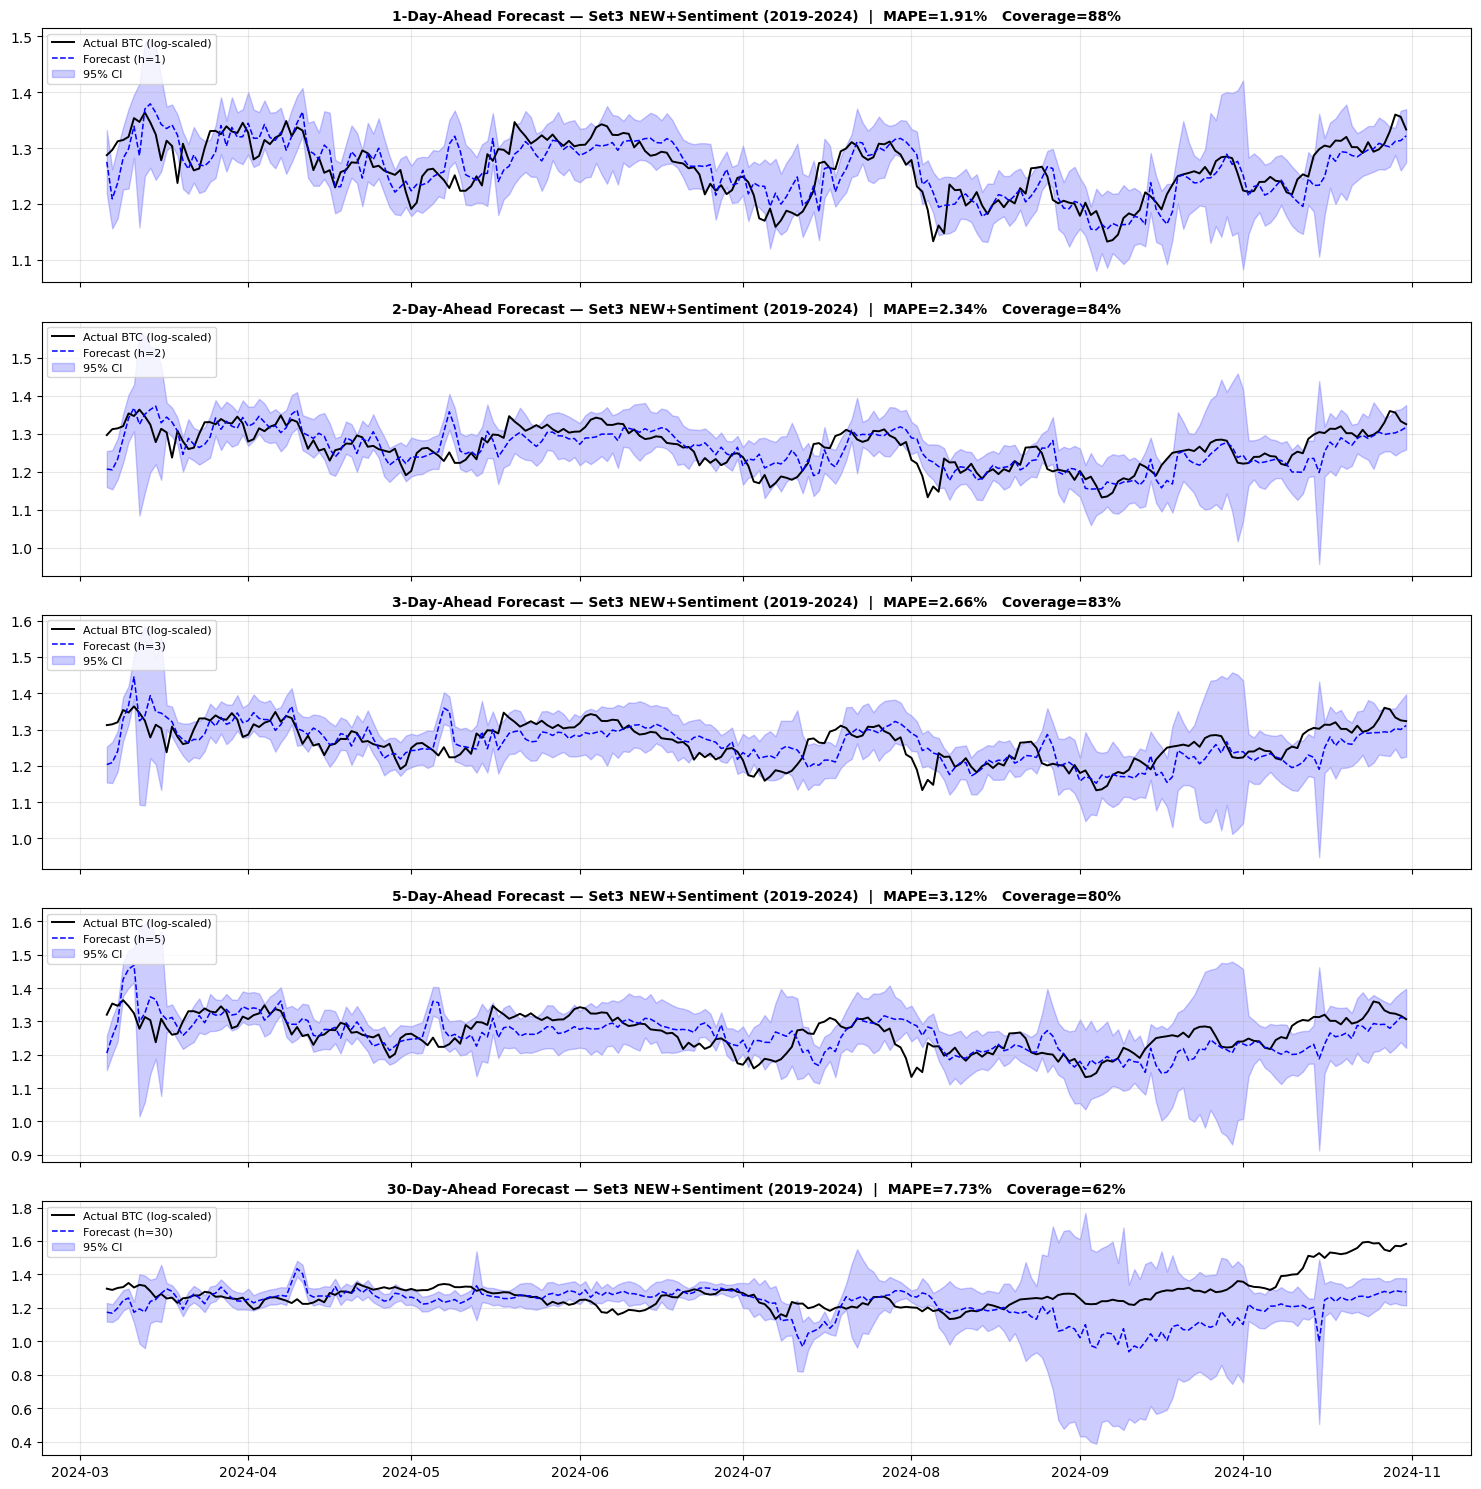

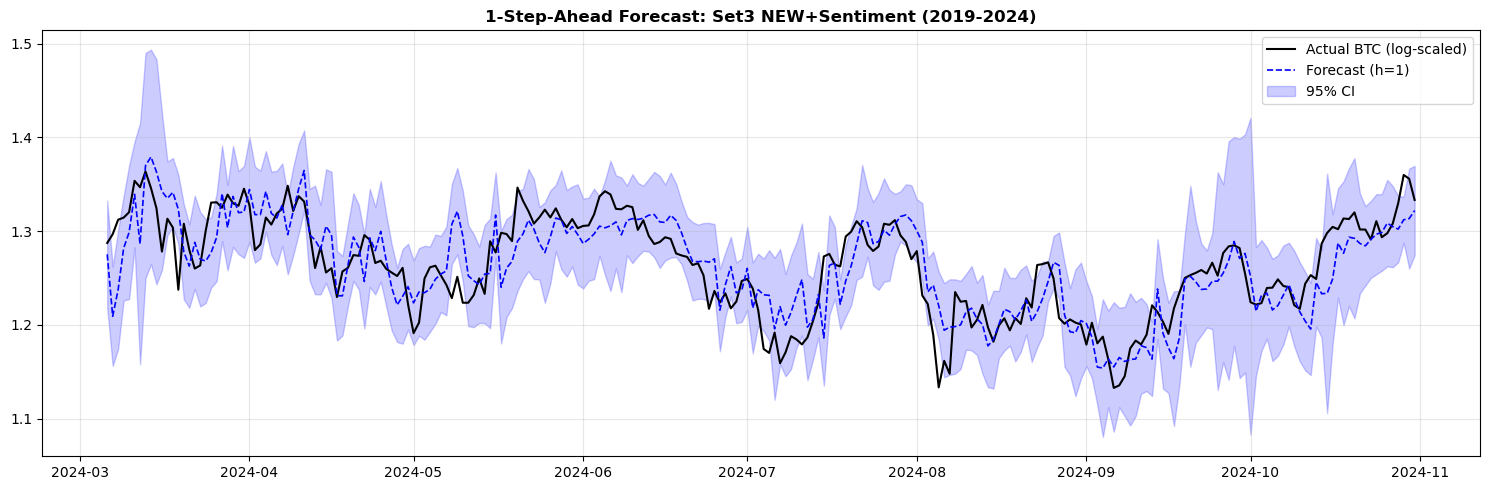

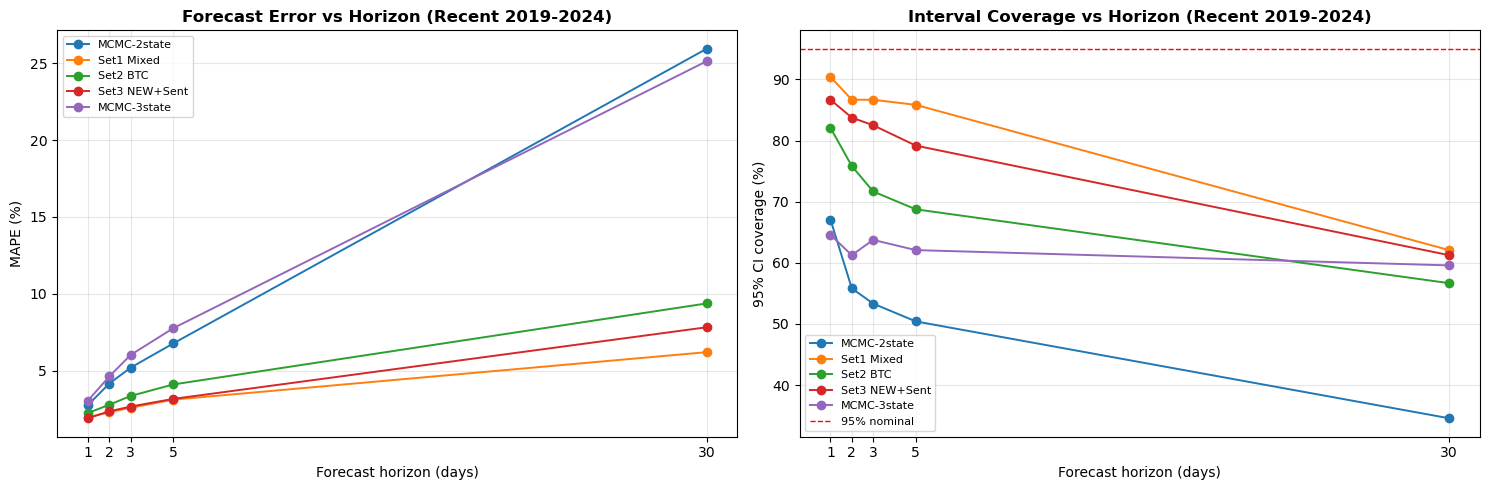


KEY FINDINGS

Early  (2016-08→2019-08)
  2-State selected : ['DJI', 'IXIC', 'SPX', 'VIX', 'INFL', 'EURUSD', 'GC_F', 'CL_F', 'BLOCK', 'MINER', 'HALVING', 'ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED', 'VOL', 'GBPUSD', 'HASH', 'CNYUSD', 'JPYUSD']
  3-State selected : ['DJI', 'IXIC', 'SPX', 'VIX', 'INFL', 'EURUSD', 'GC_F', 'CL_F', 'VOL', 'BLOCK', 'HASH', 'MINER', 'HALVING', 'ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED', 'GBPUSD', 'JPYUSD', 'CNYUSD']
  ★ New vars selected: 2-state=['ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED'] | 3-state=['ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED']

Recent (2019-09→2024-12)
  2-State selected : ['DJI', 'IXIC', 'SPX', 'INFL', 'EURUSD', 'GBPUSD', 'GC_F', 'CL_F', 'VOL', 'HASH', 'MINER', 'HALVING', 'ETH_USD', 'US10Y', 'FEDFUNDS', 'VIX', 'BLOCK', 'FEAR_GREED', 'JPYUSD', 'CNYUSD']
  3-State selected : ['DJI', 'IXIC', 'SPX', 'VIX', 'INFL', 'EURUSD', 'GBPUSD', 'GC_F', 'CL_F', 'BLOCK', 'HASH', 'MINER', 'HALVING', 'ETH_USD', 'US10Y', 'FEDFUNDS', 'FEAR_GREED', 'VOL',

In [10]:
# ── CELL 9: Results Summary ────────────────────────────────────────────────────
rows = []
for key, mets in all_metrics.items():
    period, vs = key.split('|')
    tag = '★' if 'NEW' in vs or 'Sent' in vs else ('3S' if '3state' in vs else '')
    for h, m in mets.items():
        rows.append({'Period': period, 'Set': f'{tag}{vs}', 'h': h,
                     'MAE': m['MAE'], 'RMSE': m['RMSE'],
                     'MAPE(%)': m['MAPE%'], 'Coverage(%)': m['Cov%']})

res_df = pd.DataFrame(rows)

# Pivot: rows=Period+Set, cols=horizon
pivot = res_df.pivot_table(index=['Period','Set'], columns='h',
                            values=['MAE','MAPE(%)','Coverage(%)'])
pivot.columns = [f'h={c[1]}|{c[0]}' for c in pivot.columns]
print('='*80)
print('FORECASTING RESULTS  (★=new vars with sentiment, 3S=3-state model)')
print('='*80)
display(pivot.round(3).style
        .highlight_min(axis=0, subset=[c for c in pivot.columns if 'MAPE' in c], color='#d5f5e3')
        .highlight_min(axis=0, subset=[c for c in pivot.columns if 'MAE|' in c],  color='#d6eaf8')
        .format('{:.3f}'))

# Best model per period at h=1
print('\n' + '='*60)
print('BEST MODEL PER PERIOD at h=1 (lowest MAPE)')
h1 = res_df[res_df.h == 1].copy()
best = h1.loc[h1.groupby('Period')['MAPE(%)'].idxmin()]
display(best[['Period','Set','MAE','RMSE','MAPE(%)','Coverage(%)']].reset_index(drop=True))

# ── Multi-horizon forecast plots (h = 1, 2, 3, 5, 30) ─────────────────────────
# Re-run the best model (Set3 NEW+Sentiment) on the recent period for all horizons
sub_plot  = df_model['2019-09-01':'2024-11-30'].tail(EVAL_N)
best_vars = ['ETH_USD','US10Y','FEDFUNDS','FEAR_GREED','VOL']
best_vars = [v for v in best_vars if v in sub_plot.columns]
H_PLOT    = [1, 2, 3, 5, 30]
_, recs_plot = rolling_forecast(sub_plot[TARGET].values, sub_plot[best_vars].values,
                                  K=2, window=80, h_list=H_PLOT, n_boot=80)

# Panel figure: one row per horizon (2, 3, 5, 30 day forecasts + 1-step reference)
fig, axes = plt.subplots(len(H_PLOT), 1, figsize=(15, 3.0*len(H_PLOT)), sharex=True)
for ax, h in zip(axes, H_PLOT):
    r = recs_plot.get(h)
    if not r or not r['act']:
        ax.set_visible(False); continue
    a, pr = np.array(r['act']), np.array(r['pred'])
    lo, hi = np.array(r['lo']), np.array(r['hi'])
    idx_p  = sub_plot.index[80:80+len(a)]
    mape = np.mean(np.abs((a-pr)/(np.abs(a)+1e-10)))*100
    cov  = np.mean((a>=lo)&(a<=hi))*100
    ax.plot(idx_p, a,  'k-',  lw=1.4, label='Actual BTC (log-scaled)')
    ax.plot(idx_p, pr, 'b--', lw=1.1, label=f'Forecast (h={h})')
    ax.fill_between(idx_p, lo, hi, alpha=0.2, color='blue', label='95% CI')
    ax.set_title(f'{h}-Day-Ahead Forecast — Set3 NEW+Sentiment (2019-2024)  |  '
                 f'MAPE={mape:.2f}%   Coverage={cov:.0f}%', fontsize=10, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('forecast_multi_horizon.png', dpi=120, bbox_inches='tight'); plt.show()

# Standalone 1-step plot (kept for backward compatibility / README)
r = recs_plot[1]
idx_p = sub_plot.index[80:80+len(r['act'])]
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(idx_p, r['act'],  'k-',  lw=1.5, label='Actual BTC (log-scaled)')
ax.plot(idx_p, r['pred'], 'b--', lw=1.2, label='Forecast (h=1)')
ax.fill_between(idx_p, r['lo'], r['hi'], alpha=0.2, color='blue', label='95% CI')
ax.set_title('1-Step-Ahead Forecast: Set3 NEW+Sentiment (2019-2024)', fontsize=12, fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('forecast_h1.png', dpi=120, bbox_inches='tight'); plt.show()

# ── Error / coverage growth vs forecast horizon (recent period, all models) ───
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5))
for key, mets in all_metrics.items():
    period, vs = key.split('|')
    if 'Recent' not in period:
        continue
    hs = sorted(mets.keys())
    axL.plot(hs, [mets[h]['MAPE%'] for h in hs], marker='o', lw=1.4, label=vs)
    axR.plot(hs, [mets[h]['Cov%']  for h in hs], marker='o', lw=1.4, label=vs)
axL.set_xlabel('Forecast horizon (days)'); axL.set_ylabel('MAPE (%)')
axL.set_title('Forecast Error vs Horizon (Recent 2019-2024)', fontweight='bold')
axL.set_xticks(H_PLOT); axL.legend(fontsize=8)
axR.axhline(95, color='red', ls='--', lw=1, label='95% nominal')
axR.set_xlabel('Forecast horizon (days)'); axR.set_ylabel('95% CI coverage (%)')
axR.set_title('Interval Coverage vs Horizon (Recent 2019-2024)', fontweight='bold')
axR.set_xticks(H_PLOT); axR.legend(fontsize=8)
plt.tight_layout(); plt.savefig('error_vs_horizon.png', dpi=120, bbox_inches='tight'); plt.show()

# ── Final summary ─────────────────────────────────────────────────────────────
print('\n' + '='*70)
print('KEY FINDINGS')
print('='*70)
for label in SAMPLES:
    sel2 = [k for k,v in pip2_results[label].items() if v>=0.5]
    sel3 = [k for k,v in pip3_results[label].items() if v>=0.5]
    new2 = [v for v in sel2 if v in NEW_VARS]
    new3 = [v for v in sel3 if v in NEW_VARS]
    print(f'\n{label.strip()}')
    print(f'  2-State selected : {sel2}')
    print(f'  3-State selected : {sel3}')
    if new2 or new3: print(f'  ★ New vars selected: 2-state={new2} | 3-state={new3}')

print('''
═══════════════════════════════════════════════════════════════════
EXTENSIONS vs PAPER (future research directions implemented here)
═══════════════════════════════════════════════════════════════════
★ FEAR_GREED  → Crypto Fear & Greed Index (alternative.me)
                Aggregates Reddit posts/engagement, Twitter, surveys,
                volatility, momentum — paper Section 4: "adding sentiment
                or social-media-based indicators to capture behavioral effects"

★ 3-State HMM → Bull / Neutral / Bear (AIC comparison with 2-state above)
                Separates sideways/consolidation markets from directional moves

★ ETH_USD     → Ethereum price — crypto market breadth signal
★ US10Y       → 10-Year Treasury — risk-free rate environment
★ FEDFUNDS    → Federal Funds Rate — monetary policy cycle
═══════════════════════════════════════════════════════════════════
''')

